In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [1:08:05<00:00, 41.7kB/s]


In [3]:
classes = train_data.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
len(classes)

10

In [5]:
train = DataLoader(train_data, batch_size=64, shuffle=True)
test = DataLoader(test_data, batch_size=64)

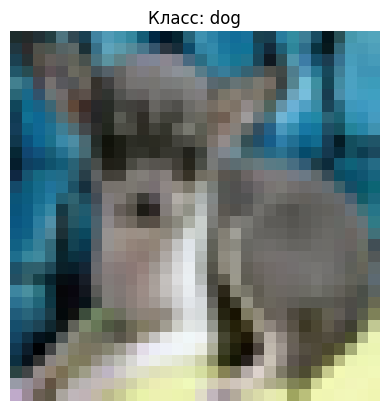

In [6]:
image, label = next(iter(train))
plt.imshow(image[0].permute(1, 2, 0))
plt.title(f'Класс: {classes[label[0]]}')
plt.axis('off')
plt.savefig('image_1')
plt.show()

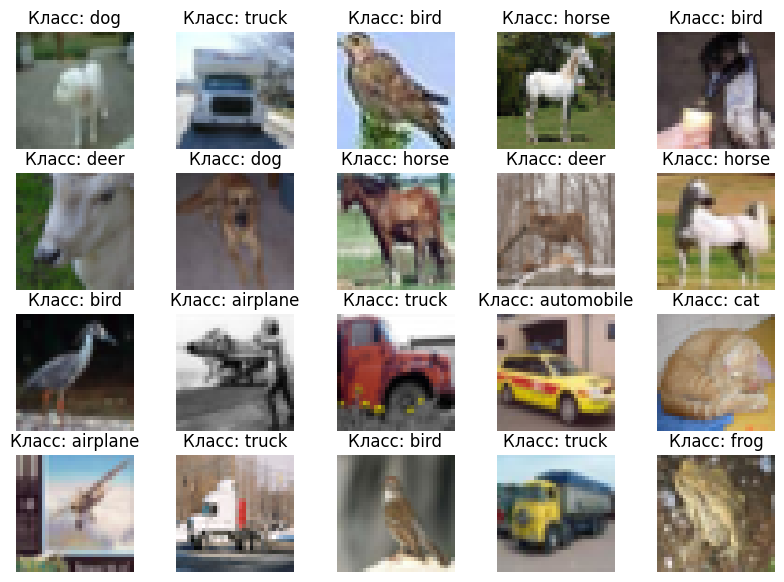

In [7]:
image, label = next(iter(train))
plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image[i].permute(1, 2, 0))
    plt.title(f'Класс: {classes[label[i]]}')
    plt.axis('off')
plt.subplots_adjust(top=0.65)
plt.savefig('image_set')
plt.show()

In [8]:
# Лучшие параметры для CifarmClassification: lr (learning rate): 0.000357844792847259 / batch_size: 64

In [9]:
class CifarClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.second = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, image):
        image = self.first(image)
        image = self.second(image)
        return image

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

Устройство: cuda


In [11]:
model = CifarClassification().to(device)

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

In [14]:
for epoch in range(30):
    model.train()
    total_loss = 0

    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        y_pred = model(x_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f'Эпоха: {epoch + 1}, Потери: {round(total_loss, 2)}%')

Эпоха: 1, Потери: 1271.63%
Эпоха: 2, Потери: 991.52%
Эпоха: 3, Потери: 845.72%
Эпоха: 4, Потери: 742.93%
Эпоха: 5, Потери: 668.83%
Эпоха: 6, Потери: 608.01%
Эпоха: 7, Потери: 568.38%
Эпоха: 8, Потери: 520.13%
Эпоха: 9, Потери: 491.14%
Эпоха: 10, Потери: 454.17%
Эпоха: 11, Потери: 429.65%
Эпоха: 12, Потери: 401.8%
Эпоха: 13, Потери: 377.47%
Эпоха: 14, Потери: 355.7%
Эпоха: 15, Потери: 334.5%
Эпоха: 16, Потери: 319.77%
Эпоха: 17, Потери: 304.23%
Эпоха: 18, Потери: 290.72%
Эпоха: 19, Потери: 271.11%
Эпоха: 20, Потери: 264.6%
Эпоха: 21, Потери: 249.65%
Эпоха: 22, Потери: 241.88%
Эпоха: 23, Потери: 229.21%
Эпоха: 24, Потери: 221.91%
Эпоха: 25, Потери: 214.33%
Эпоха: 26, Потери: 202.55%
Эпоха: 27, Потери: 196.7%
Эпоха: 28, Потери: 195.29%
Эпоха: 29, Потери: 188.61%
Эпоха: 30, Потери: 186.63%


In [15]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model(x_batch)
        prediction = torch.argmax(y_pred, dim=1)
        total += y_batch.size(0)
        correct += (prediction == y_batch).sum().item()

accuracy = correct * 100 / total
print(f'Точеность модели на тестовых данных: {round(accuracy, 2)}%')

Точеность модели на тестовых данных: 75.86%


In [28]:
torch.save(model.state_dict(), 'model_CIFAR_10.pth')